<a href="https://colab.research.google.com/github/CarlitosDamm/Actividad-5/blob/main/Actividad_5_Gestion_de_Proyectos_de_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

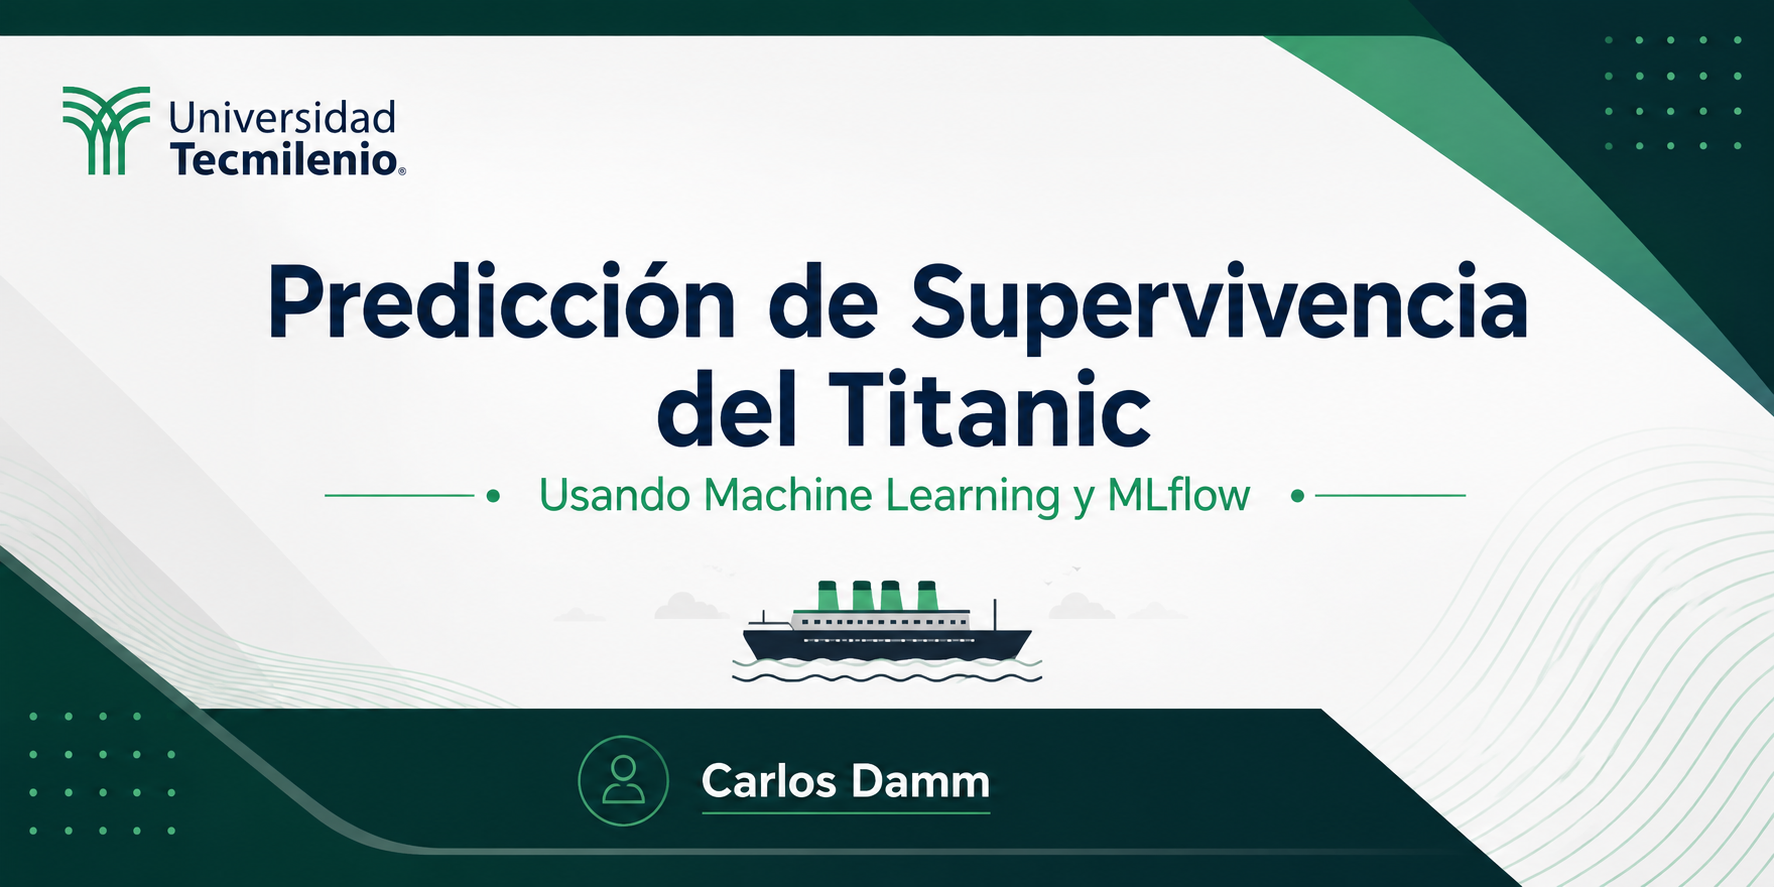

# Resumen

**Proyecto:** Predicción de supervivencia de pasajeros del Titanic usando algoritmos de clasificación supervisada y MLflow.

**Objetivo general:** comparar distintos modelos de clasificación, aplicar validación cruzada con ajuste de hiperparámetros y registrar parámetros, métricas, modelos y artefactos en MLflow.

**Dataset:** Titanic, cargado directamente desde la librería `seaborn`.

**Modelos utilizados:**

1. Regresión Logística
2. Random Forest
3. Support Vector Machine
4. Gradient Boosting

**Métricas:** accuracy, precision, recall, F1-score y ROC-AUC.

## 1. Instalación de dependencias

En Google Colab se instala MLflow para poder registrar los experimentos. Las demás librerías suelen venir preinstaladas.

In [ ]:
!pip install mlflow -q

## 2. Importación de librerías

In [ ]:
import os
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

import mlflow
import mlflow.sklearn

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)

## 3. Configuración de carpetas del proyecto

Aunque todo el flujo se ejecuta en este notebook, se crean carpetas para conservar datos, evidencias y artefactos.

In [ ]:
PROJECT_DIR = "Actividad5"
DATA_DIR = os.path.join(PROJECT_DIR, "datos")
EVIDENCE_DIR = os.path.join(PROJECT_DIR, "evidencias")
MLRUNS_DIR = os.path.join(PROJECT_DIR, "mlruns")

os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(EVIDENCE_DIR, exist_ok=True)
os.makedirs(MLRUNS_DIR, exist_ok=True)

print("Carpetas creadas:")
print(DATA_DIR)
print(EVIDENCE_DIR)
print(MLRUNS_DIR)

## 4. Obtención del dataset

El dataset se obtiene mediante `seaborn.load_dataset("titanic")`. Esto permite que el proyecto sea reproducible sin tener que estar descargando y cargando archivos.

La variable objetivo será `survived`, donde:

- `0` = no sobrevivió
- `1` = sobrevivió

In [ ]:
df_original = sns.load_dataset("titanic")

original_path = os.path.join(DATA_DIR, "titanic_original.csv")
df_original.to_csv(original_path, index=False)

print("Dimensiones del dataset original:", df_original.shape)
df_original.head()

## 5. Diccionario de datos

Como parte de la actividad, se documentan las variables principales utilizadas en el proyecto usando la informacion de la documentacion del dataset.

In [ ]:
data_dictionary = pd.DataFrame({
    "Variable": [
        "survived", "pclass", "sex", "age", "sibsp", "parch", "fare",
        "embarked", "embark_town", "alone", "adult_male"
    ],
    "Descripción": [
        "Variable objetivo. Indica si el pasajero sobrevivió.",
        "Clase del boleto del pasajero: 1, 2 o 3.",
        "Sexo del pasajero.",
        "Edad del pasajero.",
        "Número de hermanos o cónyuge a bordo.",
        "Número de padres o hijos a bordo.",
        "Tarifa pagada por el boleto.",
        "Puerto de embarque codificado.",
        "Nombre del puerto de embarque.",
        "Indica si el pasajero viajaba solo.",
        "Indica si el pasajero era hombre adulto."
    ],
    "Tipo": [
        "Binaria", "Numérica discreta", "Categórica", "Numérica continua", "Numérica discreta",
        "Numérica discreta", "Numérica continua", "Categórica", "Categórica", "Booleana", "Booleana"
    ]
})

data_dictionary

## 6. Análisis exploratorio inicial

Se revisan dimensiones del dataset, tipos de datos, valores nulos y distribución de la variable objetivo.

In [ ]:
print("Información general:")
df_original.info()

In [ ]:
missing_values = df_original.isnull().sum().sort_values(ascending=False)
missing_values[missing_values > 0]

In [ ]:
ax = sns.countplot(data=df_original, x="survived")
ax.set_title("Distribución de supervivencia")
ax.set_xlabel("Sobrevivió")
ax.set_ylabel("Cantidad de pasajeros")
plt.tight_layout()
survival_plot_path = os.path.join(EVIDENCE_DIR, "distribucion_supervivencia.png")
plt.savefig(survival_plot_path, dpi=300)
plt.show()

In [ ]:
ax = sns.countplot(data=df_original, x="sex", hue="survived")
ax.set_title("Supervivencia por sexo")
ax.set_xlabel("Sexo")
ax.set_ylabel("Cantidad")
plt.tight_layout()
sex_plot_path = os.path.join(EVIDENCE_DIR, "supervivencia_por_sexo.png")
plt.savefig(sex_plot_path, dpi=300)
plt.show()

In [ ]:
ax = sns.countplot(data=df_original, x="pclass", hue="survived")
ax.set_title("Supervivencia por clase del boleto")
ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad")
plt.tight_layout()
pclass_plot_path = os.path.join(EVIDENCE_DIR, "supervivencia_por_clase.png")
plt.savefig(pclass_plot_path, dpi=300)
plt.show()

In [ ]:
ax = sns.histplot(data=df_original, x="age", hue="survived", kde=True, bins=30)
ax.set_title("Distribución de edad por supervivencia")
ax.set_xlabel("Edad")
plt.tight_layout()
age_plot_path = os.path.join(EVIDENCE_DIR, "distribucion_edad.png")
plt.savefig(age_plot_path, dpi=300)
plt.show()

## 7. Limpieza y estandarización de datos

Tanto como buena practica, asi como por parte de las indicaciones de la actividad, se procede a realizar una limpieza a los datos originales, donde se aplica lo siguiente:

1. Se elimina `deck` porque tiene demasiados valores nulos.
2. Se eliminan columnas redundantes como `alive`, `class`, `who` y `embark_town`.
3. Se elimina `adult_male` porque se puede derivar del sexo y edad.
4. Los valores nulos son reemplazados por promedios dentro del pipeline para evitar fuga de información.
6. Las variables numéricas se escalan con `StandardScaler`.
7. Las variables categóricas se codifican con `OneHotEncoder`.

In [ ]:
df_clean = df_original.copy()

columns_to_drop = ["deck", "alive", "class", "who", "embark_town", "adult_male"]
df_clean = df_clean.drop(columns=columns_to_drop)

clean_path = os.path.join(DATA_DIR, "titanic_limpio.csv")
df_clean.to_csv(clean_path, index=False)

print("Dimensiones del dataset limpio:", df_clean.shape)
df_clean.head()

In [ ]:
print("Valores nulos después de eliminar columnas no utilizadas:")
df_clean.isnull().sum()

## 8. Separación de variables predictoras y variable objetivo

In [ ]:
target = "survived"
X = df_clean.drop(columns=[target])
y = df_clean[target]

numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked", "alone"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

## 9. Pipeline de preprocesamiento

Se crea un `ColumnTransformer` para aplicar transformaciones diferentes según el tipo de variable.

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 10. Configuración de MLflow

Se configura MLflow con seguimiento local. En Colab, los resultados se guardan dentro de la carpeta `Actividad5/mlruns`.

In [ ]:
MLRUNS_DIR = os.path.abspath("Actividad5/mlruns")
mlflow.set_tracking_uri(f"file://{MLRUNS_DIR}")
mlflow.set_experiment("actividad5_titanic_mlflow")

## 11. Definición de modelos e hiperparámetros

Se usan cuatro algoritmos para comparar diferentes enfoques de clasificación.

In [ ]:
models = {
    "Logistic Regression": {
        "estimator": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "classifier__C": [0.1, 1, 10],
            "classifier__solver": ["liblinear"]
        }
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [3, 5, None],
            "classifier__min_samples_split": [2, 5]
        }
    },
    "SVM": {
        "estimator": SVC(probability=True, random_state=42),
        "params": {
            "classifier__C": [0.1, 1, 10],
            "classifier__kernel": ["linear", "rbf"],
            "classifier__gamma": ["scale"]
        }
    },
    "Gradient Boosting": {
        "estimator": GradientBoostingClassifier(random_state=42),
        "params": {
            "classifier__n_estimators": [50, 100],
            "classifier__learning_rate": [0.05, 0.1],
            "classifier__max_depth": [2, 3]
        }
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

## 12. Función para evaluar modelos

In [ ]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    metrics = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }

    return metrics, y_pred, y_proba

## 13. Entrenamiento, validación cruzada, GridSearchCV y registro en MLflow

Para cada modelo se registra:

- Parámetros del mejor modelo
- Métricas de validación cruzada
- Métricas en conjunto de prueba
- Matriz de confusión
- Curva ROC
- Modelo entrenado

In [ ]:
results = []
trained_models = {}

for model_name, model_info in models.items():
    print(f"Entrenando modelo: {model_name}")

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model_info["estimator"])
    ])

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=model_info["params"],
        cv=cv,
        scoring="f1",
        n_jobs=-1,
        return_train_score=True
    )

    with mlflow.start_run(run_name=model_name):
        grid_search.fit(X_train, y_train)

        best_model = grid_search.best_estimator_
        metrics, y_pred, y_proba = evaluate_model(best_model, X_test, y_test)

        # Registrar parámetros
        mlflow.log_param("model_name", model_name)
        mlflow.log_param("best_params", json.dumps(grid_search.best_params_))
        mlflow.log_param("cv_folds", 5)
        mlflow.log_param("scoring", "f1")

        for param_name, param_value in grid_search.best_params_.items():
            mlflow.log_param(param_name, param_value)

        # Registrar métricas de CV
        mlflow.log_metric("best_cv_f1", grid_search.best_score_)

        # Registrar métricas de prueba
        for metric_name, metric_value in metrics.items():
            mlflow.log_metric(metric_name, metric_value)

        # Matriz de confusión
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No sobrevivió", "Sobrevivió"])
        disp.plot(values_format="d")
        plt.title(f"Matriz de confusión - {model_name}")
        plt.tight_layout()
        cm_path = os.path.join(EVIDENCE_DIR, f"confusion_matrix_{model_name.replace(' ', '_').lower()}.png")
        plt.savefig(cm_path, dpi=300)
        mlflow.log_artifact(cm_path, artifact_path="figuras")
        plt.show()

        # Curva ROC
        RocCurveDisplay.from_predictions(y_test, y_proba)
        plt.title(f"Curva ROC - {model_name}")
        plt.tight_layout()
        roc_path = os.path.join(EVIDENCE_DIR, f"roc_curve_{model_name.replace(' ', '_').lower()}.png")
        plt.savefig(roc_path, dpi=300)
        mlflow.log_artifact(roc_path, artifact_path="figuras")
        plt.show()

        # Registrar modelo
        mlflow.sklearn.log_model(
            best_model,
            name="modelo", # Changed artifact_path to name
            skops_trusted_types=['numpy.dtype', 'sklearn.compose._column_transformer._RemainderColsList']
        )

        # Guardar resultados locales
        result = {
            "model": model_name,
            "best_cv_f1": grid_search.best_score_,
            **metrics,
            "best_params": grid_search.best_params_
        }
        results.append(result)
        trained_models[model_name] = best_model

results_df = pd.DataFrame(results)
results_df

## 14. Comparación de modelos

Se construye una tabla comparativa con las métricas obtenidas en el conjunto de prueba.

In [ ]:
comparison_df = results_df[[
    "model", "best_cv_f1", "accuracy", "precision", "recall", "f1", "roc_auc"
]].sort_values(by="f1", ascending=False)

comparison_path = os.path.join(EVIDENCE_DIR, "model_comparison_results.csv")
comparison_df.to_csv(comparison_path, index=False)

comparison_df

In [ ]:
comparison_melted = comparison_df.melt(
    id_vars="model",
    value_vars=["accuracy", "precision", "recall", "f1", "roc_auc"],
    var_name="metric",
    value_name="score"
)

ax = sns.barplot(data=comparison_melted, x="model", y="score", hue="metric")
ax.set_title("Comparación de desempeño por modelo")
ax.set_xlabel("Modelo")
ax.set_ylabel("Puntaje")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
comparison_plot_path = os.path.join(EVIDENCE_DIR, "comparacion_modelos.png")
plt.savefig(comparison_plot_path, dpi=300)
plt.show()

## 15. Comparación estadística simple

Como comparación estadística práctica, se revisan las diferencias entre el mejor modelo y los demás modelos usando F1-score y ROC-AUC.

In [ ]:
best_row = comparison_df.iloc[0]
stat_comparison = comparison_df.copy()
stat_comparison["delta_f1_vs_best"] = best_row["f1"] - stat_comparison["f1"]
stat_comparison["delta_roc_auc_vs_best"] = best_row["roc_auc"] - stat_comparison["roc_auc"]
stat_comparison

## 16. Selección del mejor modelo

El modelo seleccionado será el que tenga mejor balance entre F1-score y ROC-AUC, dando prioridad al F1-score porque combina precisión y recall.

In [ ]:
best_model_name = comparison_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

print("Mejor modelo seleccionado:", best_model_name)
comparison_df.iloc[0]

## 17. Evidencia de MLflow

Debido a varios retos para generar un URL desde un entorno virtual como lo es Colab, para visualizar el panel de MLflow se debe exportar la carpeta de mlruns como zip y copiar la carpeta en la raiz de algun entorno como Visual Studio, desde ahi se puede ejecutar Mlflow y visualizar. Esta linea ayuda a descargar la carpeta a formato zip.

In [ ]:
!zip -r mlruns.zip Actividad5/mlruns

## 18. Conclusiones

En este proyecto se implementó un flujo básico de MLOps utilizando MLflow. El dataset Titanic permitió trabajar con variables numéricas, categóricas y valores nulos, por lo que fue necesario aplicar limpieza, imputación, escalado y codificación.

Se compararon cuatro algoritmos de clasificación mediante GridSearchCV y validación cruzada estratificada. Los resultados se registraron en MLflow, incluyendo parámetros, métricas, artefactos gráficos y modelos entrenados.

Desde una perspectiva de deuda técnica, el proyecto podría mejorar al incorporar pruebas automatizadas, validación de datos, control de versiones de datasets con herramientas especializadas y despliegue del modelo mediante una API o pipeline automatizado.